# P10 | Food Distribution — Bronze Source Profiling
## Clarivance Analytics Group

**Analyst:** Esther Uzor
**Date:** 28 July 2026
**Dataset:** Ingrifoods operational extract — orders, deliveries, products, depots

### Objective
Profile the four raw source extracts *before* they are modelled, and produce a
defect register that the Silver data quality contracts will be written against.

### Why this comes first
Contracts invented before looking at data test imagination. Contracts derived
from profiling test the data. This notebook is the evidence base for every
`fail-closed` rule in `src/contracts/`.

### Deviation from the standard EDA framework
The Clarivance 7-phase EDA framework assumes a single table with a target
column. This is a four-table relational extract with no target, so Phase 6
(bivariate vs target) and Phase 7 (multicollinearity) are replaced by
**referential integrity** and **business-rule** checks — the failure modes that
actually matter in a lakehouse ingestion layer.

---
## Section 2 — Environment

In [1]:
# ── Data manipulation ────────────────────────────────────────
import pandas as pd
import numpy as np
from pathlib import Path

# ── Visualisation ────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Configuration ────────────────────────────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid')

# Clarivance brand colours
NAVY  = '#0D1F3C'   # Midnight Navy — titles
TEAL  = '#00B4A6'   # Signal Teal   — primary series
GOLD  = '#F5A623'   # Amber Gold    — warnings
RED   = '#E03E3E'   # Signal Red    — defects
GREEN = '#2ECC8F'   # Sage Green    — healthy
GREY  = '#8A9BB0'   # Cool Grey     — baselines

FIGDIR = Path('../docs/eda')
FIGDIR.mkdir(parents=True, exist_ok=True)

# display() is an IPython builtin — fall back to print if run as a plain script
try:
    display
except NameError:
    display = print

print("Environment ready.")

Environment ready.


---
## Section 3 — Load the raw extracts

Loaded with **no type coercion and no parsing**. Reading raw exactly as the
source system produced it is the point — if a date arrives as a string or a
flag arrives as text, that is a finding, not an inconvenience to be silently
fixed on import.

In [2]:
RAW = Path('../data/raw')

tables = {
    'products':   pd.read_csv(RAW / 'products.csv'),
    'depots':     pd.read_csv(RAW / 'depots.csv'),
    'orders':     pd.read_csv(RAW / 'orders.csv'),
    'deliveries': pd.read_csv(RAW / 'deliveries.csv'),
}

for name, df in tables.items():
    print(f"{name:<12} {df.shape[0]:>7,} rows  x  {df.shape[1]} cols")

products          52 rows  x  7 cols
depots            12 rows  x  6 cols
orders        17,912 rows  x  9 cols
deliveries     5,546 rows  x  9 cols


---
## Phase 1 — Shape & schema audit

Looking for columns whose storage type disagrees with their meaning: dates held
as strings, flags held as objects, numerics that arrived as text because one bad
value poisoned the whole column.

In [3]:
def schema_audit(name, df):
    out = pd.DataFrame({
        'dtype': df.dtypes.astype(str),
        'non_null': df.notna().sum(),
        'nulls': df.isna().sum(),
        'null_pct': (df.isna().sum() / len(df) * 100).round(2),
        'n_unique': df.nunique(),
        'sample': [df[c].dropna().iloc[0] if df[c].notna().any() else None
                   for c in df.columns],
    })
    print(f"\n{'='*72}\n{name.upper()}  —  {len(df):,} rows\n{'='*72}")
    display(out)
    return out

audits = {name: schema_audit(name, df) for name, df in tables.items()}


PRODUCTS  —  52 rows


,dtype,non_null,nulls,null_pct,n_unique,sample
product_id,str,52,0,0.0,50,P0001
product_name,str,52,0,0.0,50,Basmati Rice 5kg
category,str,52,0,0.0,5,Ambient
temperature_zone,str,52,0,0.0,3,AMBIENT
unit_cost,float64,52,0,0.0,49,9.13
unit_price,float64,52,0,0.0,50,10.79
shelf_life_days,int64,52,0,0.0,37,520



DEPOTS  —  12 rows


,dtype,non_null,nulls,null_pct,n_unique,sample
depot_id,str,12,0,0.0,12,D001
depot_name,str,12,0,0.0,12,Ingrifoods Manchester
city,str,12,0,0.0,12,Manchester
region,str,12,0,0.0,10,North West
capacity_pallets,int64,12,0,0.0,12,1107
opened_date,str,12,0,0.0,12,2018-03-31



ORDERS  —  17,912 rows


,dtype,non_null,nulls,null_pct,n_unique,sample
order_id,str,17912,0,0.00,6000,ORD000001
order_line_id,str,17912,0,0.00,17829,ORD000001-01
customer_id,str,17912,0,0.00,480,CUST0390
depot_id,str,17912,0,0.00,15,D004
product_id,str,17912,0,0.00,50,P0038
order_datetime,str,17912,0,0.00,5948,2026-03-25 15:17:00
requested_delivery_date,str,17701,211,1.18,371,2026-04-01
quantity,int64,17912,0,0.00,64,13
unit_price,float64,17912,0,0.00,329,6.41



DELIVERIES  —  5,546 rows


,dtype,non_null,nulls,null_pct,n_unique,sample
delivery_id,str,5546,0,0.00,5546,DEL000001
order_id,str,5546,0,0.00,5546,ORD000001
depot_id,str,5546,0,0.00,12,D004
vehicle_id,str,5546,0,0.00,140,VH069
dispatched_at,str,5546,0,0.00,5393,2026-04-01 08:37:00
delivered_at,str,5546,0,0.00,5456,2026-04-01 13:37:00
status,str,5546,0,0.00,9,DELIVERED
temperature_breach_flag,object,5450,96,1.73,2,False
distance_km,float64,5546,0,0.00,1925,33.9


**Your read.** Which columns are stored as the wrong type, and which of those
matter? Not every string-typed date is a problem — but a flag column that is
`object` instead of `bool` usually means something non-boolean got in.

---
## Phase 2 — Missingness: count *and* pattern

A count tells you how much is missing. The pattern tells you whether it is
random or systematic — and systematic missingness is informative, not noise.
If a column is null only when another column takes a particular value, that is
a finding worth a contract.

In [4]:
for name, df in tables.items():
    miss = (pd.DataFrame({'nulls': df.isna().sum(),
                          'pct': (df.isna().sum() / len(df) * 100).round(2)})
            .query('nulls > 0').sort_values('pct', ascending=False))
    if len(miss):
        print(f"\n{name}:")
        display(miss)
    else:
        print(f"\n{name}: no nulls")


products: no nulls

depots: no nulls

orders:


,nulls,pct
requested_delivery_date,211,1.18



deliveries:


,nulls,pct
temperature_breach_flag,96,1.73


**Your investigation.** For each column with nulls, test whether the
missingness is random. Pick one and slice the data by another column to see
whether nulls concentrate anywhere. Write down what you find.

In [ ]:
# YOUR CODE — is the missingness random or systematic?


---
## Phase 3 — Key integrity: uniqueness and duplication

Every table has a column that is *supposed* to be unique. Where it isn't, every
downstream join silently multiplies rows — and the number that reaches a
dashboard is wrong in a way nobody notices for months.

In [5]:
candidate_keys = {
    'products':   'product_id',
    'depots':     'depot_id',
    'orders':     'order_line_id',
    'deliveries': 'delivery_id',
}

for name, key in candidate_keys.items():
    df = tables[name]
    n_rows, n_keys = len(df), df[key].nunique()
    dup_keys = n_rows - n_keys
    full_dupes = df.duplicated().sum()
    flag = 'OK ' if dup_keys == 0 else 'DUP'
    print(f"[{flag}] {name:<12} {key:<16} "
          f"rows={n_rows:>7,}  distinct={n_keys:>7,}  "
          f"dup_keys={dup_keys:>5,}  identical_rows={full_dupes:>5,}")

[DUP] products     product_id       rows=     52  distinct=     50  dup_keys=    2  identical_rows=    2
[OK ] depots       depot_id         rows=     12  distinct=     12  dup_keys=    0  identical_rows=    0
[DUP] orders       order_line_id    rows= 17,912  distinct= 17,829  dup_keys=   83  identical_rows=   76
[OK ] deliveries   delivery_id      rows=  5,546  distinct=  5,546  dup_keys=    0  identical_rows=    0


**Your read.** Where a key duplicates, inspect the offending rows. Are they
byte-identical (a double-load) or genuinely different records sharing a key
(a source-system bug)? The two need different contracts.

In [ ]:
# YOUR CODE — inspect the duplicate rows

---
## Phase 4 — Numeric distributions and impossible values

Two different questions, and it is worth keeping them apart:

- **Outlier** — unusual but possible. A 210 km delivery is long, not wrong.
- **Impossible** — violates the definition of the column. A negative distance
  is not a large number in the wrong direction; it is not a distance at all.

Outliers get investigated. Impossible values get a fail-closed contract.

In [6]:
def numeric_profile(name, df):
    num = df.select_dtypes(include='number')
    if num.empty:
        return
    prof = pd.DataFrame({
        'min': num.min(), 'p05': num.quantile(0.05),
        'median': num.median(), 'p95': num.quantile(0.95),
        'max': num.max(), 'mean': num.mean().round(2),
        'skew': num.skew().round(2),
        'n_negative': (num < 0).sum(),
        'n_zero': (num == 0).sum(),
    })
    print(f"\n{name}:")
    display(prof.round(2))

for name, df in tables.items():
    numeric_profile(name, df)


products:


,min,p05,median,p95,max,mean,skew,n_negative,n_zero
unit_cost,1.91,2.89,9.88,13.55,14.41,9.06,-0.50,0,0
unit_price,2.29,3.80,13.26,19.02,22.79,12.33,-0.23,0,0
shelf_life_days,2.00,3.55,17.50,516.15,532.00,142.85,0.93,0,0



depots:


,min,p05,median,p95,max,mean,skew,n_negative,n_zero
capacity_pallets,412,532.45,1115.5,1978.0,2121,1211.17,0.19,0,0



orders:


,min,p05,median,p95,max,mean,skew,n_negative,n_zero
quantity,-12.00,3.00,30.00,57.0,60.00,30.33,-0.01,53,11
unit_price,1.28,4.05,13.35,19.3,36.83,12.60,-0.12,0,0



deliveries:


,min,p05,median,p95,max,mean,skew,n_negative,n_zero
distance_km,-190.9,13.2,107.3,199.2,210.0,106.52,-0.11,14,0


Distribution grid — the visual pass. Look for values clustered where they
should not be, and for tails that run past the edge of what the column can
legitimately mean.

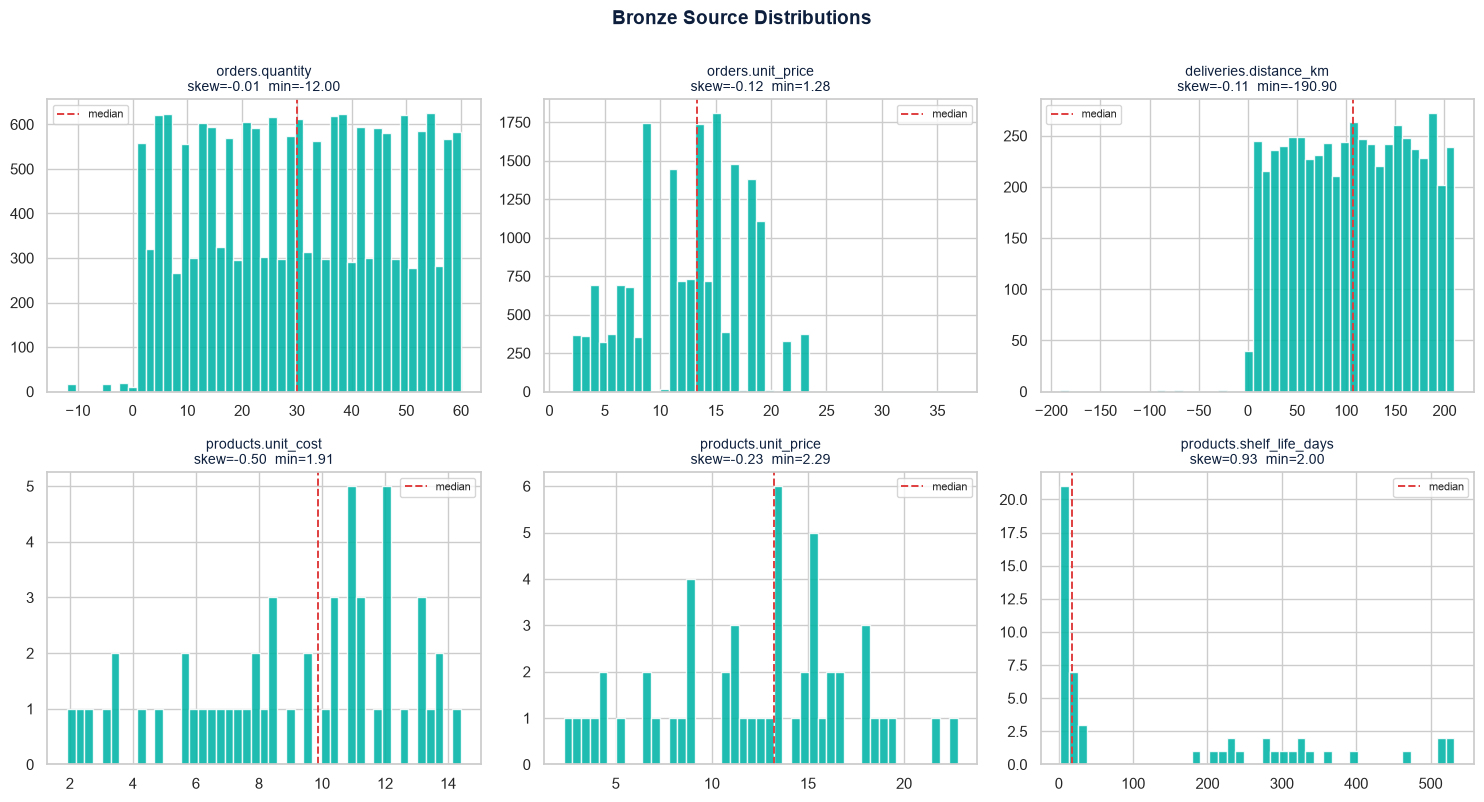

In [7]:
num_targets = [
    ('orders', 'quantity'), ('orders', 'unit_price'),
    ('deliveries', 'distance_km'),
    ('products', 'unit_cost'), ('products', 'unit_price'),
    ('products', 'shelf_life_days'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (tname, col) in zip(axes.flatten(), num_targets):
    s = tables[tname][col].dropna()
    ax.hist(s, bins=45, color=TEAL, edgecolor='white', alpha=0.88)
    ax.axvline(s.median(), color=RED, linestyle='--', lw=1.4, label='median')
    ax.set_title(f'{tname}.{col}\nskew={s.skew():.2f}  min={s.min():,.2f}',
                 fontsize=10, color=NAVY)
    ax.legend(fontsize=8)

plt.suptitle('Bronze Source Distributions', fontsize=14,
             fontweight='bold', color=NAVY, y=1.00)
plt.tight_layout()
plt.savefig(FIGDIR / 'eda_01_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Phase 5 — Categorical conformance

The classic silent killer: `'DELIVERED'`, `'Delivered'` and `' DELIVERED'` are
three different strings and one real category. Every `GROUP BY` splits them,
every count is wrong, and nothing errors.

In [8]:
def categorical_profile(name, df, max_card=60):
    cats = df.select_dtypes(include='object')
    for col in cats.columns:
        n_unique = df[col].nunique()
        if n_unique > max_card:
            print(f"{name}.{col}: {n_unique:,} distinct — high cardinality, skipped")
            continue
        vc = df[col].value_counts(dropna=False)
        print(f"\n{name}.{col}  ({n_unique} distinct)")
        display(vc.to_frame('count').head(20))

for name in ['products', 'depots', 'deliveries']:
    categorical_profile(name, tables[name])


products.product_id  (50 distinct)


C:\Users\enuzo\AppData\Local\Temp\ipykernel_12404\675415528.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cats = df.select_dtypes(include='object')


,count
product_id,
P0008,2
P0032,2
P0001,1
P0002,1
P0003,1
P0004,1
P0005,1
P0006,1
P0007,1



products.product_name  (50 distinct)


,count
product_name,
Plain Flour 1.5kg,2
Carrots 5kg,2
Basmati Rice 5kg,1
Penne Pasta 500g,1
Chopped Tomatoes 400g,1
Olive Oil 1L,1
Baked Beans 415g,1
Sunflower Oil 2L,1
Caster Sugar 1kg,1


...

,count
depot_id,
D005,492
D004,486
D010,483
D008,467
D012,466
D011,465
D009,459
D007,450
D003,448


deliveries.vehicle_id: 140 distinct — high cardinality, skipped
deliveries.dispatched_at: 5,393 distinct — high cardinality, skipped
deliveries.delivered_at: 5,456 distinct — high cardinality, skipped

deliveries.status  (9 distinct)


,count
status,
DELIVERED,4637
FAILED,257
RETURNED,211
PARTIAL,151
DELIVERED,63
delivered,60
Delivered,58
DELIVERED,55
failed,54



deliveries.temperature_breach_flag  (2 distinct)


,count
temperature_breach_flag,
False,5236
True,214
NaN,96


**Your read.** Which of these columns contain the same real-world value more
than once under different spellings? A useful trick: compare the raw distinct
count against the distinct count after `.str.strip().str.upper()`. If the two
numbers disagree, you have a conformance defect and you know its size.

In [ ]:
# YOUR CODE — quantify the conformance gap

---
## Phase 6 — Referential integrity *(replaces bivariate-vs-target)*

Every foreign key is a promise: *this value exists in the parent table*. Broken
promises do not raise errors — they quietly drop rows at join time, and the
total on the dashboard comes out low with no indication why.

One worked example below. **The rest are yours** — there are four more foreign
key relationships in this schema.

In [9]:
def fk_check(child_df, child_col, parent_df, parent_col, label):
    child_vals = child_df[child_col].dropna()
    orphan_mask = ~child_vals.isin(parent_df[parent_col])
    n_orphan = int(orphan_mask.sum())
    n_distinct = child_vals[orphan_mask].nunique()
    pct = n_orphan / len(child_vals) * 100 if len(child_vals) else 0
    status = 'PASS' if n_orphan == 0 else 'FAIL'
    print(f"[{status}] {label:<42} orphans={n_orphan:>6,} "
          f"({pct:.2f}%)  distinct_bad_keys={n_distinct}")
    if n_orphan:
        print(f"         offending values: "
              f"{sorted(child_vals[orphan_mask].unique())[:10]}")
    return n_orphan


# WORKED EXAMPLE
fk_check(tables['orders'], 'product_id',
         tables['products'], 'product_id',
         'orders.product_id -> products')

[PASS] orders.product_id -> products              orphans=     0 (0.00%)  distinct_bad_keys=0


0

**Your turn.** Write the remaining foreign key checks. The relationships to
test are the ones implied by the schema — think about which columns in one
table are meant to point at another. Reuse `fk_check`; it takes five arguments
and prints its own verdict.

In [21]:
# YOUR CODE — the remaining foreign key checks

fk_check(tables['deliveries'], 'order_id',
         tables['orders'], 'order_id',
         'deliveries.order_id -> orders')

fk_check(tables['orders'], 'depot_id',
         tables['depots'], 'depot_id',
         'orders.depot_id -> depots')

fk_check(tables['deliveries'], 'depot_id',  
         tables['depots'], 'depot_id',
         'deliveries.depot_id -> depots')

[FAIL] deliveries.order_id -> orders              orphans=    33 (0.60%)  distinct_bad_keys=33
         offending values: ['ORD990001', 'ORD990002', 'ORD990003', 'ORD990004', 'ORD990005', 'ORD990006', 'ORD990007', 'ORD990008', 'ORD990009', 'ORD990010']
[FAIL] orders.depot_id -> depots                  orphans=   124 (0.69%)  distinct_bad_keys=3
         offending values: ['D014', 'D017', 'D099']
[PASS] deliveries.depot_id -> depots              orphans=     0 (0.00%)  distinct_bad_keys=0


0

---
## Phase 7 — Business rules *(replaces multicollinearity)*

The defects that no generic profiler will ever catch, because they are not
statistical — they are violations of how the business actually works. Each one
is a candidate **singular test** in dbt.

One worked example. **At least three more are findable** in this schema.

In [13]:
def rule_check(mask, label, df=None):
    n = int(mask.sum())
    status = 'PASS' if n == 0 else 'FAIL'
    print(f"[{status}] {label:<52} violations={n:>6,}")
    if n and df is not None:
        display(df[mask].head(5))
    return n


# WORKED EXAMPLE — a delivery cannot complete before it departs
d = tables['deliveries'].copy()
d['dispatched_at'] = pd.to_datetime(d['dispatched_at'])
d['delivered_at']  = pd.to_datetime(d['delivered_at'])

rule_check(d['delivered_at'] < d['dispatched_at'],
           'delivered_at earlier than dispatched_at', d)

[FAIL] delivered_at earlier than dispatched_at              violations=    48


,delivery_id,order_id,depot_id,vehicle_id,dispatched_at,delivered_at,status,temperature_breach_flag,distance_km
224,DEL000225,ORD000239,D004,VH072,2026-07-02 07:56:00,2026-07-02 04:56:00,DELIVERED,False,133.7
292,DEL000293,ORD000311,D004,VH051,2025-10-27 07:16:00,2025-10-27 04:16:00,DELIVERED,False,185.4
293,DEL000294,ORD000312,D003,VH025,2026-05-05 08:26:00,2026-05-05 05:26:00,DELIVERED,False,152.3
303,DEL000304,ORD000323,D007,VH113,2026-02-05 04:07:00,2026-02-05 01:07:00,DELIVERED,False,155.8
366,DEL000367,ORD000388,D010,VH107,2025-12-25 08:53:00,2025-12-25 05:53:00,DELIVERED,False,158.0


48

**Your turn.** What else must be true in a food distribution business that a
schema cannot enforce? Consider: the relationship between an order and its
delivery in time · the relationship between cost and price on a product ·
what a quantity is allowed to be · what a distance is allowed to be · whether
an order line's price should agree with the product master.

Write a `rule_check` for each rule you can articulate.

In [20]:
# Rule 2:  nothing can be dispatched before the order was placed
o = tables['orders'].copy()
o['order_datetime'] = pd.to_datetime(o['order_datetime'])

order_times = o.groupby('order_id')['order_datetime'].min().reset_index()
chk = d.merge(order_times, on='order_id', how='inner')

rule_check(chk['dispatched_at'] < chk['order_datetime'],
           'dispatched before the order was placed', chk)

# Rule 3:  nothing can be delivered before the order was placed
rule_check(chk['delivered_at'] < chk['order_datetime'],
           'delivered before the order was placed', chk)    

[PASS] dispatched before the order was placed               violations=     0
[PASS] delivered before the order was placed                violations=     0


0

In [22]:
# Row 11 — size the conformance gap
s = tables['deliveries']['status']
print(f"non-conforming status rows: {(s != s.str.strip().str.upper()).sum():,}")

# The missing FK check
fk_check(tables['deliveries'], 'depot_id',
         tables['depots'], 'depot_id',
         'deliveries.depot_id -> depots')

non-conforming status rows: 290
[PASS] deliveries.depot_id -> depots              orphans=     0 (0.00%)  distinct_bad_keys=0


0

---
## Defect register — the deliverable

This table is the whole point of the notebook. Everything above is evidence;
this is the finding. Each row becomes a data quality contract in
`src/contracts/`, and the **Action** column is the judgement call.

**Fail-closed** — the pipeline stops. Use when the defect makes downstream
numbers *wrong* rather than *incomplete*: broken keys, duplicated grain,
impossible values, violated business rules.

**Warn** — the row is quarantined or flagged and the pipeline continues. Use
when the defect is tolerable, expected at some background rate, or when
stopping would cause more harm than the bad data.

**Cleanse** — silver fixes it deterministically. Use for conformance issues
where the correct value is unambiguous, e.g. trimming and upper-casing a status.

| # | Table | Column(s) | Defect | Rows | Action | Rationale |
|---|--------|-------------|----------------------------|----------|--------------------|-----------|
| 1 | orders |	customer_id	No parent table in extract	Document   Degenerate dimension; no RI rule possible
     deliveries	vehicle_id	No parent table in extract	Document	Degenerate dimension; no RI rule possible
> Fill this in from what you actually found. Row counts must come from the
> checks above — not estimates. The rationale column is what a reviewer reads.

---
## Summary — carry into F-A silver

| Check | Finding | Contract |
|-------|---------|----------|
| Schema / dtypes |  |  |
| Missingness |  |  |
| Key uniqueness |  |  |
| Impossible values |  |  |
| Categorical conformance |  |  |
| Referential integrity |  |  |
| Business rules |  |  |

**Commit message when done:**
`[EDA] Bronze source profiling complete — N defects registered across 4 tables`